# Överlevnadsanalys av tid till avhopp för en studentkohort


## Sammanfattning

**Kontext.** Ett kontor för institutionell forskning vid ett fyraårigt college vill förstå *när*, inte bara *om*, studenter hoppar av. En förstagångskohort följs termin för termin från antagning; några tar examen, några hoppar av, och ett fåtal är fortfarande inskrivna när observationsfönstret stängs. Eftersom utfallet för fortfarande inskrivna studenter är okänt (högercensurerat), och eftersom examen tar bort en student från riskpoolen utan att vara ett avhopp, kastar vanlig godkänd/underkänd-regression bort tidsinformationen och snedvrider varje skattning som ignorerar censurering. Rätt verktyg är **tid-till-händelse-analys (överlevnadsanalys)**, där händelsen av intresse är **avhopp** och klockan mäts i antal inskrivna akademiska terminer.

**Affärsfråga.** Separerar en students **akademiska ställning under första terminen** (en tidig varningsflagga) kohortens avhoppstidsbanor, och vilka studentegenskaper driver avhoppsrisken efter justering? Svaren matar in i ett system för tidig varning: studenter vars skattade avhoppsrisk är hög bör få vägledande kontakt under sina första terminer, när intervention är billigast och mest effektiv.

**Angreppssätt.** Vi simulerar en kohort på 100 studenter direkt i koden (inga externa data) och arbetar sedan igenom ett standardiserat överlevnadsflöde:

1. **PROC MEANS** profilerar prediktorerna över de tre observerade utfallen (Examen / Avhopp / fortfarande Inskriven) för att bekräfta att den simulerade signalen beter sig rimligt.
2. **PROC FREQ** korstabulerar akademisk ställning under första terminen mot utfall med ett chi-två-test för association.
3. **PROC UNIVARIATE** rapporterar robusta percentiler av tid till avhopp per ställning.
4. **PROC LIFETEST** skattar Kaplan-Meier-avhoppskurvor stratifierade efter ställning och kör **log-rank**- och **Wilcoxon**-test för likhet.
5. **PROC PHREG** anpassar en multivariabel **Cox-proportionell-hasard**-modell för avhoppsrisken, med en referenskodad `CLASS`-effekt, Efron-hantering av bindningar och konfidensintervall för riskgränser.

**Vad data visar.** Av de 100 simulerade studenterna **hoppade 49 av, 49 tog examen och 2 förblev inskrivna** vid gränsen på 12 terminer. Studenter som flaggades för **akademisk varning** under sin första termin (första terminens GPA under 2,5) hoppar av mycket snabbare än studenter i god ställning: median-tid-till-avhopp **3,8 terminer mot 8,7 terminer**, en separation som log-rank-testet bekräftar (chi-två = 10,73, *p* = 0,0011). Cox-modellen identifierar första terminens GPA (hasardkvot 0,21 per GPA-poäng, *p* < 0,0001), gymnasie-GPA (HR 0,45, *p* = 0,027) och status som första generationens student (HR 2,03, *p* = 0,031) som signifikanta justerade drivkrafter för avhopp, medan Pell-bidragsstatus inte är signifikant när GPA kontrolleras för (HR 0,95, *p* = 0,85).

> *Alla siffror är illustrativa och genererade från syntetiska data; de är inte verkliga studentregister. Denna miljö körs utan licens, så kohorten är dimensionerad till 100 studenter.*


## Datakällor

Alla data är **syntetiska**, genererade direkt i koden i det första DATA-steget med `CALL STREAMINIT(20260611)` och funktionen `RAND`. Inga externa filer eller nätverksåtkomst. En rad per simulerad student.

**Datamängd `inskrivningar`** (100 rader, en rad per student)

| Variabel | Typ | Beskrivning | Genererande fördelning |
|----------|------|-------------|--------------------------|
| `student_id` | Num | Unik studentnyckel | sekvens 1–100 |
| `forsta_gen` / `forsta_gen_txt` | Num / Char | Flagga för första generationen (0/1) och etikett | Bernoulli, ~42 % |
| `pell` | Num | Flagga för Pell-bidrag (ekonomiskt behov) (0/1) | Bernoulli, ~42 % |
| `program` | Char | STEM / BUS / HUM | kategorisk (~42 % / 32 % / 26 %) |
| `gymn_gpa` | Num | Gymnasie-GPA (1,8–4,0) | Normal(3,00, 0,42), begränsad |
| `termin1_gpa` | Num | Första terminens college-GPA (0–4,0) | f(gymn_gpa, program) + Normal-brus |
| `stallning` | Char | Akademisk ställning första terminen | `termin1_gpa < 2.5` → Akademisk varning, annars God ställning |
| `antal_terminer` | Num | Inskrivna terminer fram till händelse eller censurering | konkurrerande Weibull-dragningar; begränsad till 12 |
| `avhoppad` | Num | Indikator för avhoppshändelse (1 = avhopp, 0 = censurerad) | härledd |
| `utfall` | Char | Examen / Avhopp / Inskriven | härledd från konkurrerande dragningar |

En latent linjär prediktor på log-skalan kopplar varje students **avhoppstakt** till första terminens GPA, gymnasie-GPA, status som första generationens student och ekonomiskt behov, så att prediktorerna bär en genuin men brusig signal. Avhopp och examen dras som **konkurrerande** latenta tider (Weibull); den som inträffar först inom ett 12-terminersfönster blir det observerade utfallet, och studenter som når termin 12 utan endera högercensureras. För överlevnadsmodellerna är **händelsen avhopp** (`avhoppad = 1`); examen och pågående inskrivning behandlas båda som censurering (`avhoppad = 0`).


## 1. Simulera studentkohorten

Den första cellen bygger en syntetisk kohort på 100 studenter. En latent linjär prediktor på log-skalan knyter varje students avhoppstakt till första terminens GPA, gymnasie-GPA, status som första generationens student och Pell-status. Avhopp och examen genereras som **konkurrerande** latenta tider (Weibull-dragningar); den som inträffar först inom ett 12-terminers observationsfönster blir det observerade utfallet, och studenter som når termin 12 utan att hoppa av eller ta examen högercensureras. En första terminens GPA under 2,5 flaggar studenten för **akademisk varning** — den tidiga varningssignal vi testar i överlevnadssteget. Slumpmässiga dragningar använder `CALL STREAMINIT` för reproducerbarhet och funktionen `RAND` över Uniform-, Normal- och Weibull-fördelningar. Hårda golv och begränsningar håller varje värde trovärdigt (GPA i 0–4,0).


In [1]:
data inskrivningar;
    CALL streaminit(20260611);
    LÄNGD stallning $24 forsta_gen_txt $32 program $4 utfall $12;
    ETIKETT student_id     = "Student-ID"
          forsta_gen     = "Första generationen (0/1)"
          forsta_gen_txt = "Generationsstatus"
          pell           = "Pell-bidrag (0/1)"
          program        = "Program"
          gymn_gpa       = "Gymnasie-GPA"
          termin1_gpa    = "Första terminens GPA"
          stallning      = "Akademisk ställning"
          antal_terminer = "Inskrivna terminer"
          avhoppad       = "Avhoppsindikator"
          utfall         = "Utfall";
    GÖR student_id = 1 TILL 100;
        /* Flaggor för första generationen och ekonomiskt behov */
        forsta_gen = (rand("uniform") < 0.42);
        OM forsta_gen SÅ forsta_gen_txt = "Första generationen";
        ANNARS               forsta_gen_txt = "Ej första generationen";
        pell = (rand("uniform") < 0.42);

        /* Studieprogram */
        v = rand("uniform");
        OM      v < 0.42 SÅ program = "STEM";
        ANNARS OM v < 0.74 SÅ program = "BUS";
        ANNARS                  program = "HUM";

        /* Akademisk förberedelse och första terminens resultat */
        gymn_gpa = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        termin1_gpa = round(MIN(4.0, MAX(0.0,
                     0.55*gymn_gpa + 1.05 + 0.12*(program="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Tidig varningsflagga: första terminens GPA under 2,5 = akademisk varning */
        OM termin1_gpa < 2.5 SÅ stallning = "Akademisk varning";
        ANNARS                      stallning = "God ställning";

        /* Latent avhoppsrisk på log-skalan: lägre GPA, första
           generationen och Pell-status höjer avhoppstakten. */
        eta = -1.05
             - 1.45*(termin1_gpa - 2.8)
             - 0.55*(gymn_gpa - 3.0)
             + 1.05*forsta_gen
             + 0.45*pell;
        avhoppstakt = EXP(eta);

        /* Konkurrerande latenta tider (terminer): avhopp mot examen */
        t_avhopp = rand("weibull", 1.2, 7.0) / MAX(0.30, avhoppstakt);
        t_examen = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(termin1_gpa - 2.8));

        /* Administrativt censureringsfönster på 12 terminer */
        censur_vid = 12;
        OM t_avhopp <= t_examen AND t_avhopp <= censur_vid SÅ GÖR;
            utfall = "Avhopp";    avhoppad = 1; antal_terminer = t_avhopp;
        SLUT;
        ANNARS OM t_examen < t_avhopp AND t_examen <= censur_vid SÅ GÖR;
            utfall = "Examen";    avhoppad = 0; antal_terminer = t_examen;
        SLUT;
        ANNARS GÖR;
            utfall = "Inskriven"; avhoppad = 0; antal_terminer = censur_vid;
        SLUT;
        antal_terminer = round(antal_terminer, 0.1);
        UTDATA;
    SLUT;
    BEHÅLL student_id forsta_gen forsta_gen_txt pell program gymn_gpa
         termin1_gpa stallning antal_terminer avhoppad utfall;
KÖR;



NOTE: DATA inskrivningar


NOTE: Wrote inskrivningar (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Profilera prediktorer per observerat utfall

Innan vi modellerar bekräftar vi att de simulerade prediktorerna rör sig i förväntade riktningar. **PROC MEANS** rapporterar antal, medelvärde, spridning och intervall för varje numerisk prediktor inom de tre observerade utfallen.

Kohorten fördelar sig på **49 Examen / 49 Avhopp / 2 fortfarande Inskriven**. De som tar examen bär en högre första terminens GPA (medelvärde **2,94** mot **2,54** för studenter som hoppade av) och en högre gymnasie-GPA (**3,10** mot **2,90**) — precis den akademiska förberedelsegradient analysen förväntar sig. De två fortfarande inskrivna studenterna ligger exakt vid censureringstaket på 12 terminer i `antal_terminer` (medelvärde 12,00, standardavvikelse 0), den högercensurering en avhoppsanalys måste respektera. Bland studenter som hoppade av inträffar händelsen tidigt: medelvärde **3,31 terminer**, med spann från 0,1 till 8,9.


In [2]:
PROCEDUR MEDELVÄRDEN data=inskrivningar n mean std MIN MAX maxdec=2;
    KLASS utfall;
    VARIABEL gymn_gpa termin1_gpa antal_terminer;
KÖR;


                                                  The MEANS Procedure

                                       Analysis Variable : gymn_gpa Gymnasie-GPA

        Utfall             N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        Avhopp                49           2.90           0.45           2.01           3.89
        Examen                49           3.10           0.46           1.97           4.00
        Inskriven              2           3.10           0.17           2.98           3.22
        ------------------------------------------------------------------------------------

                                 Analysis Variable : termin1_gpa Första terminens GPA

        Utfall             N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        Avhopp 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Följer den tidiga varningsflaggan utfallet?

Systemet för tidig varning flaggar varje student vars första terminens GPA faller under 2,5 för **akademisk varning**. **PROC FREQ** korstabulerar den flaggan mot det observerade utfallet och kör ett chi-två-test för association. Vi undertrycker rad-, kolumn- och totalprocent (`NOROW NOCOL NOPERCENT`) så att tabellen visar råa antal, och lägger till envägsfrekvenser av `stallning` och status som första generationens student för kohortens sammansättning.

Korstabellen är tydlig: av de **29** studenter som flaggades för akademisk varning **hoppade 21 av** och endast 8 tog examen; av de **71** i god ställning **tog 41 examen** och 28 hoppade av. Associationen är signifikant (chi-två = 9,21, df = 2, *p* = 0,0100; Cramérs V = 0,30). Notera **varningen som skrivs ut med den**: med 100 studenter och en tunn "Inskriven"-kolumn med två examinerade har en tredjedel av tabellcellerna förväntade antal under 5, så chi-två-*p*-värdet är skört här. Just den skörheten är exakt varför överlevnadstesten i nästa avsnitt — som använder den fullständiga tidsinformationen snarare än en 3×2-tabell — är det mer pålitliga testet av ställningseffekten.


                                                   The FREQ Procedure

Table of Akademisk ställning by Utfall

Akademisk ställning  |    Avhopp |    Examen | Inskriven |      Total
---------------------+-----------+-----------+-----------+-----------
Akademisk varning    |        21 |         8 |         0 |         29
---------------------+-----------+-----------+-----------+-----------
God ställning        |        28 |        41 |         2 |         71
---------------------+-----------+-----------+-----------+-----------
Total                |        49 |        49 |         2 |        100

Statistics for Table of Akademisk ställning by Utfall

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               2 9.8909       0.0071

Cramer's V                           0.3035
Contingency Coefficient              0.2904


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_stallning_utfall.spec.json
NOTE: ODS plot written: freq_stallning.spec.json
NOTE: ODS plot written: freq_forsta_gen_txt.spec.json
NOTE: PROC FREQ statement used.


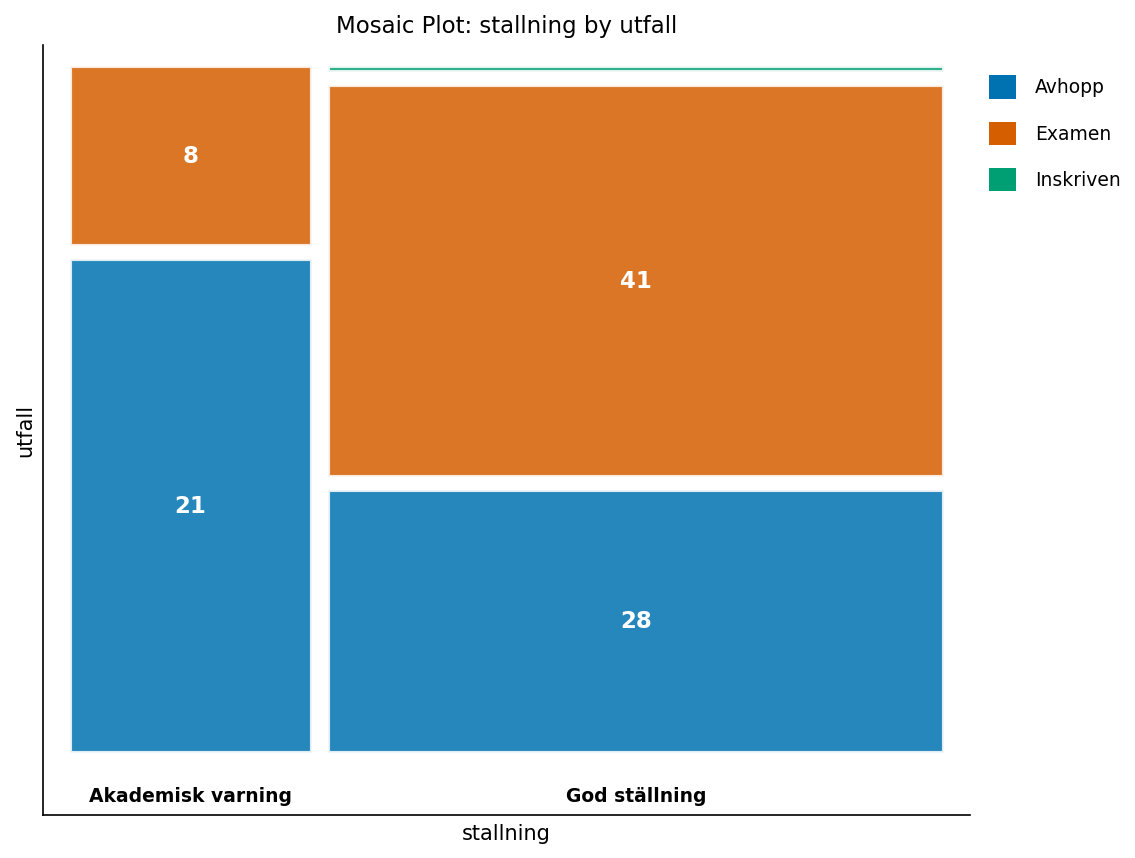

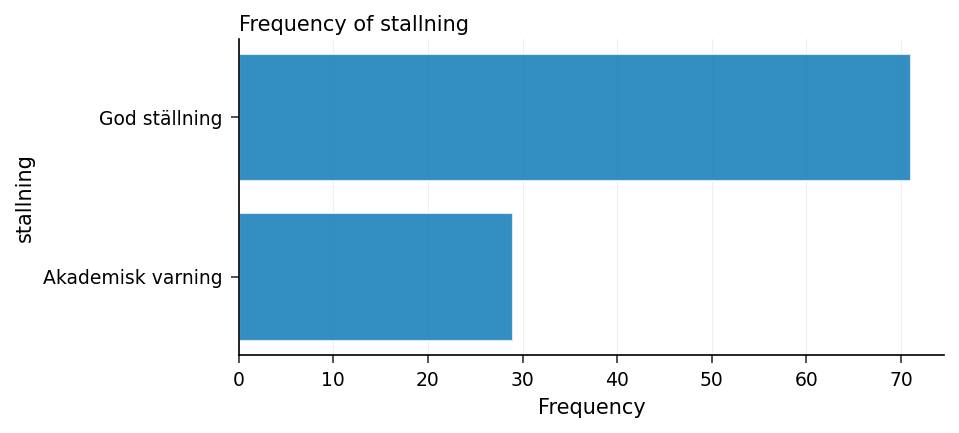

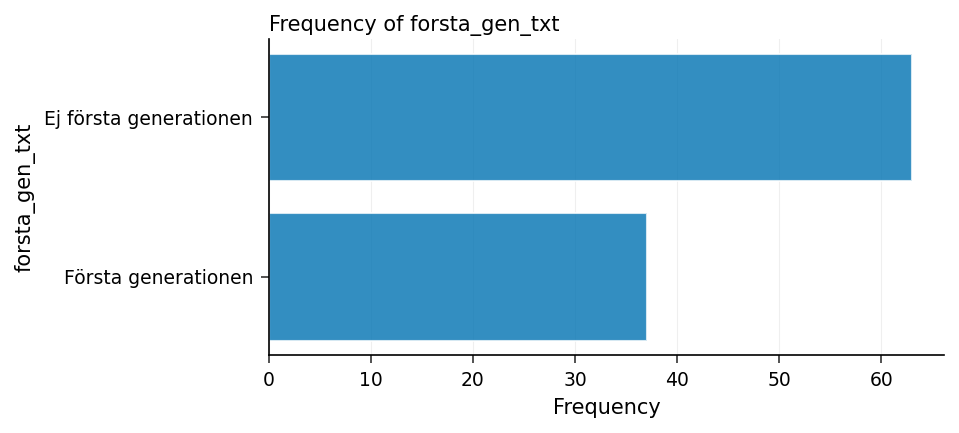

In [3]:
PROCEDUR FREKVENSER data=inskrivningar;
    TABLES stallning*utfall / chisq norow nocol nopercent;
    TABLES stallning forsta_gen_txt;
KÖR;


## 4. När sker avhoppen? Percentiler per ställning

För de studenter som faktiskt hoppade av, *när* lämnade de? **PROC UNIVARIATE** (begränsad till `avhoppad = 1`) rapporterar den 10:e, 50:e (median) och 90:e percentilen av tid till avhopp inom varje ställningsgrupp, skrivet till en utdatamängd som vi sedan skriver ut. Detta beskriver spridningen i avhoppstiming utan att anta en fördelning.

Median-avhoppet bland studenter som lämnade inträffar runt termin **2,4** (akademisk varning) mot **2,6** (god ställning) — nära varandra, eftersom *betingat på avhopp* tenderar båda grupperna att lämna tidigt. Ställningseffekten handlar därför inte främst om *när* ett avhopp sker utan om *hur många* studenter som hoppar av och hur snabbt riskpoolen tunnas ut, vilket är precis vad Kaplan-Meier-kurvorna i nästa avsnitt fångar.


In [4]:
PROCEDUR UNIVARIATE data=inskrivningar NOPRINT;
    DÄR avhoppad = 1;
    KLASS stallning;
    VARIABEL antal_terminer;
    UTDATA out=avhopp_ref pctlpts=10 50 90 pctlpre=t_ p=;
KÖR;

PROCEDUR SKRIV data=avhopp_ref noobs ETIKETT;
    ETIKETT t_10 = "10:e percentilen (terminer)"
          t_50 = "Median (terminer)"
          t_90 = "90:e percentilen (terminer)";
    TITEL "Percentiler för tid till avhopp (terminer), per akademisk ställning";
KÖR;
TITEL;


                          Percentiler för tid till avhopp (terminer), per akademisk ställning                           

        STALLNING  10:e percentilen (terminer)  Median (terminer)  90:e percentilen (terminer)
Akademisk varning                          0.2                2.4                          7.9
God ställning                              0.4                2.6                          8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset avhopp_ref has 2 observations and 4 variables.
NOTE: PROC PRINT data=avhopp_ref

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Kaplan-Meier-avhoppskurvor per akademisk ställning

Nu kärnsteget i överlevnadsanalysen. **PROC LIFETEST** skattar den ickeparametriska **Kaplan-Meier**-överlevnadsfunktionen för *tid till avhopp*, och behandlar examen och pågående inskrivning som censurering (`avhoppad(0)` markerar de censurerade observationerna). Stratifiering efter `stallning` ger en avhoppskurva per grupp, och `TEST=(LOGRANK WILCOXON)` kör två kompletterande test av huruvida dessa kurvor skiljer sig åt: **log-rank**-testet viktar alla händelsetider lika (känsligt för sena skillnader), medan **Wilcoxon**-testet uppviktar tidiga händelsetider (känsligt för tidigt avhopp). `PLOTS=SURVIVAL` begär den överlagrade överlevnadskurvgrafiken.

Över hela kohorten finns **49 avhoppshändelser och 51 censurerade** observationer. Kurvorna separerar tydligt: studenter på akademisk varning når **median-överlevnad (tid-till-avhopp) på 3,8 terminer**, medan studenter i god ställning håller mer än dubbelt så länge (**8,7 terminer**). Båda testen förkastar likhet — **log-rank chi-två = 10,73, *p* = 0,0011; Wilcoxon chi-två = 7,66, *p* = 0,0056** — och de jämförbara statistikorna säger oss att gapet består över hela inskrivningsfönstret, inte bara vid en tidig topp. Diagrammet gör budskapet omedelbart: den orangea akademisk-varning-kurvan faller brant genom de första fyra terminerna, medan den blå god-ställning-kurvan förblir hög.


    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: Akademisk ställning = Akademisk varning

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7556     0.0804  


NOTE: PROC LIFETEST data=inskrivningar

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


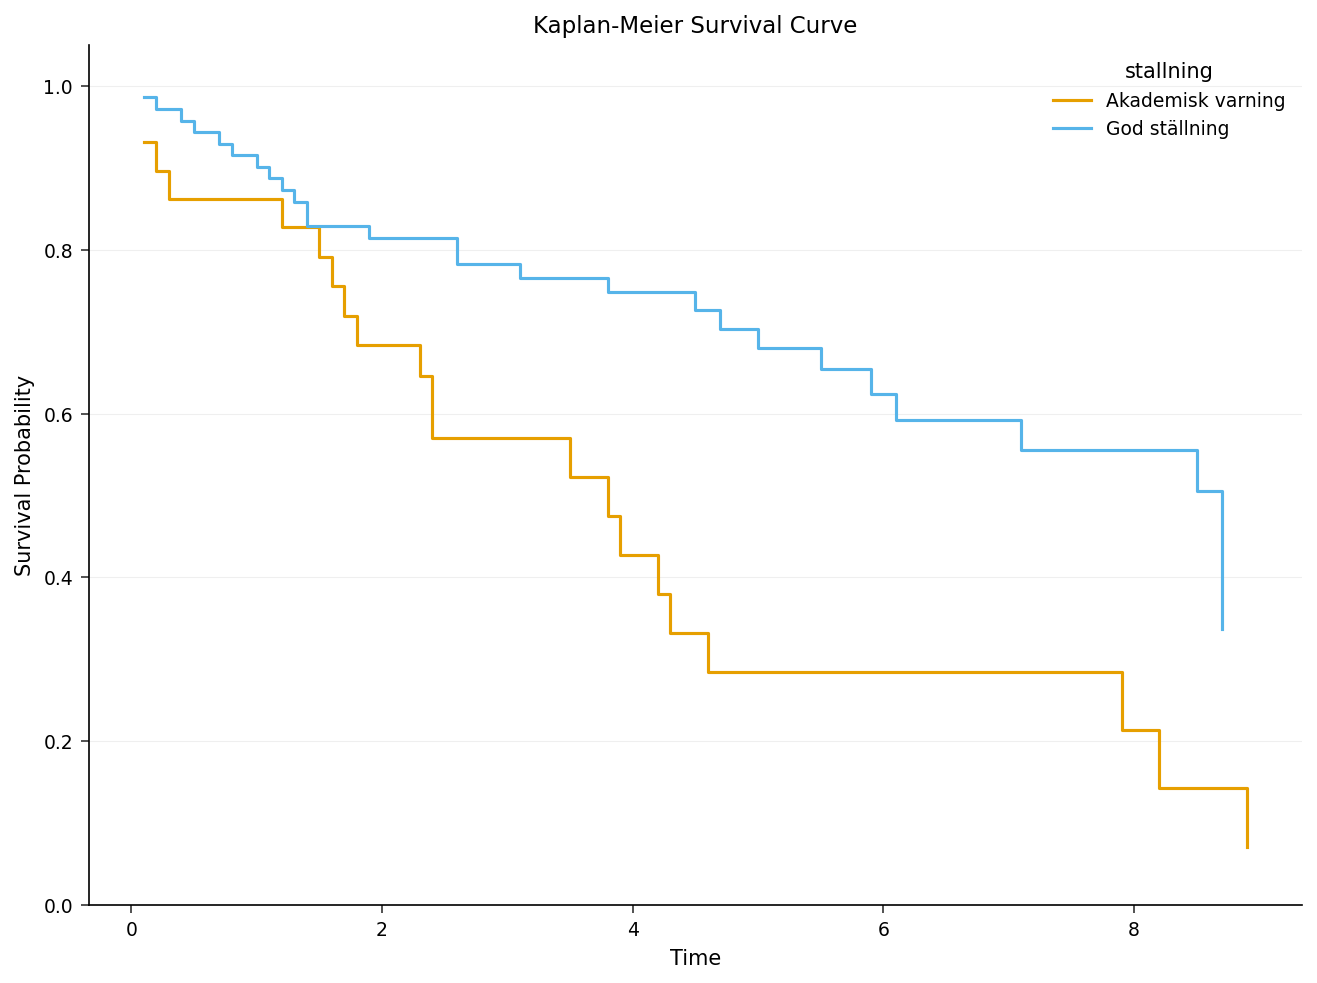

In [5]:
PROCEDUR LIFETEST data=inskrivningar PLOTS=SURVIVAL METHOD=km;
    TIME antal_terminer*avhoppad(0);
    STRATA stallning / TEST=(logrank WILCOXON);
KÖR;


## 6. Multivariabel Cox-proportionell-hasard-modell för avhopp

**PROC PHREG** anpassar **Cox-proportionell-hasard**-modellen för avhoppsrisken och justerar prediktorerna samtidigt. Viktiga anrop:

- `avhoppad(0)` gör **avhopp** till händelsen och allt annat censurerat.
- `CLASS forsta_gen_txt (ref="Ej första generationen") / param=ref` referenskodar faktorn för första generationen så att dess hasardkvot avläses mot studenter som inte är första generationen.
- `TIES=EFRON` är den rekommenderade approximationen för bindningshantering när flera studenter lämnar under samma termin.
- `RL` lägger till konfidensintervall för hasardkvoten (riskgränser).
- `HAZARDRATIO`-satsen rapporterar kontrasten för första generationen mot referensgruppen.

En hasardkvot över 1 betyder *snabbare* avhopp (högre risk); under 1 betyder *långsammare* avhopp (skyddande).


In [6]:
PROCEDUR PHREG data=inskrivningar;
    KLASS forsta_gen_txt (REF="Ej första generationen") / PARAM=REF;
    MODEL antal_terminer*avhoppad(0) = gymn_gpa termin1_gpa forsta_gen_txt pell
          / TIES=efron rl;
    hazardratio "Första generationen mot ej första" forsta_gen_txt / DIFF=REF;
KÖR;


        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                                Analysis of Maximum Likelihood Estimates                                                 

Parameter                                  DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-----------------------------------  --------  --------  --------------  ----------  ----------  ------------  ------------  


NOTE: PROC PHREG data=inskrivningar

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Tolkning och nästa steg

**Läsning av utdata, från början till slut:**

- **PROC MEANS** bekräftar den simulerade signalen: studenter som tog examen bär en högre första terminens GPA (2,94 mot 2,54) och gymnasie-GPA (3,10 mot 2,90) än studenter som hoppade av, och de fortfarande inskrivna studenterna ligger vid taket på 12 terminer — den högercensurering överlevnadsmodellerna respekterar.
- **PROC FREQ** visar att flaggan för akademisk varning under första terminen följer utfallet (21 av 29 flaggade studenter hoppade av; 41 av 71 studenter i god ställning tog examen; *p* = 0,0100), samtidigt som den ärligt flaggar att chi-två är skört i en tabell med 100 studenter och glesa celler.
- **PROC UNIVARIATE** visar att *betingat på avhopp* lämnar båda grupperna tidigt (median ~2,4–2,6 terminer); ställningseffekten handlar om hur många studenter som hoppar av och hur snabbt riskpoolen tunnas ut, inte om timingen bland dem som lämnar.
- **PROC LIFETEST** levererar huvudbudskapet: Kaplan-Meier-avhoppskurvor som separerar skarpt efter ställning (median 3,8 mot 8,7 terminer; log-rank *p* = 0,0011, Wilcoxon *p* = 0,0056). Den tidiga varningsflaggan är en genuin, statistiskt understödd diskriminator av avhoppstiming.
- **PROC PHREG** kvantifierar varje prediktors justerade effekt på avhoppsrisken. Efter justering är **första terminens GPA den starkaste skyddande faktorn** (hasardkvot 0,21 per GPA-poäng, 95 % KI 0,10–0,44, *p* < 0,0001): varje ytterligare GPA-poäng minskar avhoppsrisken med ungefär fyra femtedelar. **Gymnasie-GPA** är också skyddande (HR 0,45, 95 % KI 0,22–0,91, *p* = 0,027). **Första generationens studenter** möter ungefär dubbelt så hög avhoppsrisk som jämnåriga som inte är första generationen med samma GPA (HR 2,03, 95 % KI 1,07–3,84, *p* = 0,031). **Pell-status är inte signifikant** när GPA kontrolleras för (HR 0,95, 95 % KI 0,53–1,69, *p* = 0,85) — en användbar påminnelse om att en rå riskfaktor kan tvättas ut efter justering. Den globala nollhypotesen förkastas övertygande (likelihood-kvot chi-två = 31,11 på 4 df, *p* < 0,0001).

**Hur en institution skulle agera på detta.** Cox-modellen producerar en linjär prediktor per student (riskpoäng) som rangordnar kohorten efter avhoppsrisk; studenterna med högst risk — låg första terminens GPA i kombination med status som första generationens student — dirigeras till tidig-varning-vägledning under sina första terminer, när intervention är billigast och mest effektiv. Kaplan-Meier-jämförelsen ger vägledare ett enda, försvarbart kriterium som de redan samlar in vid slutet av termin ett: akademisk ställning.

**Förbehåll och utökningar.** (1) Denna syntetiska kohort behandlar examen som censurering för avhoppsmodellen; med verkliga data är examen och avhopp genuina **konkurrerande risker**, och en utökning med konkurrerande risker (kumulativ incidens) via PROC PHREG `EVENTCODE=` skulle undvika att överskatta avhoppssannolikheten. (2) Antagandet om proportionella hasarder bör kontrolleras (PHREG `ASSESS PH` eller Schoenfeld-residualer) innan man litar på en enda hasardkvot över alla terminer. (3) Tidsvarierande kovariater — GPA termin för termin, förändringar i studiestöd, kursbelastning — är vanliga i kvarhållningsdata och hanteras naturligt av PHREG-programmeringssatser. (4) Kohorten på 100 studenter här är dimensionerad efter taket för olicensierade körningar; en produktionsanalys skulle bära flera tusen studenter, vilket skulle strama åt varje konfidensintervall. Validera alltid en driftsatt riskpoäng på en avskild kohort innan du agerar på den operativt.
